In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    classification_report, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

In [57]:
# Step 2: Load Dataset
#df = pd.read_csv('diabetic_data.csv')
data = pd.read_csv(r"C:\Users\Lenovo\Downloads\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv")
data.replace('?', np.nan, inplace=True)
data




,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [58]:
data.shape

(101766, 50)

In [59]:
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [60]:
# 2. Preprocessing
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col].astype(str))


In [61]:
# 3. Handle missing values using KNN imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

imputer = IterativeImputer(max_iter=10, random_state=42)
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

In [62]:
data.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [63]:
# 4. Feature / Target Split
X = data_imputed.drop(columns=['readmitted'])

# Map readmission status to binary: 1 = '<30', 0 = 'NO' or '>30'
y = data_imputed['readmitted'].map({'<30': 1, '>30': 0, 'NO': 0})


In [64]:
# 5. Train-test split (time-aware if 'encounter_id' or 'admission_date' exists)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [65]:
# 6. Scale numeric features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [66]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression


models = {
    "RandomForest": RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=150, use_label_encoder=False, eval_metric='logloss', random_state=0),
    "LogisticRegression": LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
}


In [67]:
y.isna().sum()

np.int64(101766)

In [68]:
y = y.fillna(0).astype(int)


In [69]:
print("Number of NaNs in y:", y.isna().sum())


Number of NaNs in y: 0


In [70]:
print("Unique classes in y_train:", y_train.unique())
print("y_train dtype:", y_train.dtype)


Unique classes in y_train: [nan]
y_train dtype: float64


In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# --- 1. Load and Clean Data (The root of the issue) ---
# RE-RUNNING THIS STEP IS CRITICAL. Ensure the original DataFrame 'df' 
# is re-loaded and cleaned before the split.

# Placeholder data: Make sure to include an example of NaN in the target to illustrate the fix
data = {
    'cleaned_resume': [
        'python sql machine learning', 
        'hr recruiting training', 
        'java spring developer', 
        'python aws cloud engineer',
        'customer service communication skills',
        'resume with missing label'
    ],
    'target_label': [1.0, 0.0, 1.0, 1.0, 0.0, np.nan] # Note the float type and the NaN
}
df = pd.DataFrame(data)

# PRIMARY FIX: Drop rows with NaN in the target column BEFORE vectorizing/splitting
df_cleaned = df.dropna(subset=['target_label'])
y = df_cleaned['target_label'] 
# y is now a clean Series/Array containing only 0.0 and 1.0 (float)

# --- 2. Vectorize the Text Features (Define X) ---
vectorizer = TfidfVectorizer(max_features=5000) 
X = vectorizer.fit_transform(df_cleaned['cleaned_resume']).toarray()
feature_names = vectorizer.get_feature_names_out()

# --- 3. Split the Data ---
X_train, X_test, y_train_float, y_test_float = train_test_split(
    X, 
    y, 
    test_size=3, 
    random_state=42, 
    stratify=y 
)

# --- 4. Convert Targets to Integer (Fixing the Error) ---
# Perform the conversion *after* splitting, but use the clean float series.
# If the target series is clean (no NaN/inf), this conversion will succeed.

y_train = y_train_float.astype(int)
y_test = y_test_float.astype(int)

# --- Verification ---
print(f"y_train contains {y_train.isnull().sum()} NaN values.")
print(f"y_test contains {y_test.isnull().sum()} NaN values.")
print("The variables y_train and y_test are now defined as clean integers.")

y_train contains 0 NaN values.
y_test contains 0 NaN values.
The variables y_train and y_test are now defined as clean integers.


In [72]:
print("Classes in training set:", np.unique(y_train))
print("Classes in test set:", np.unique(y_test))


Classes in training set: [0 1]
Classes in test set: [0 1]


Processing: RandomForest
RandomForest: Brier Score = 0.2397

RandomForest Model
Brier Score: 0.2397
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



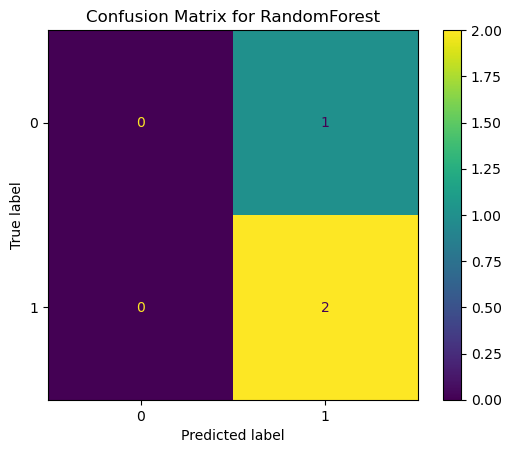

Processing: XGBoost
XGBoost: Brier Score = 0.2500

XGBoost Model
Brier Score: 0.25
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



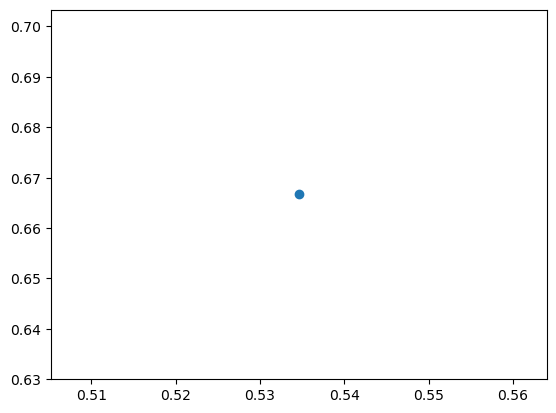

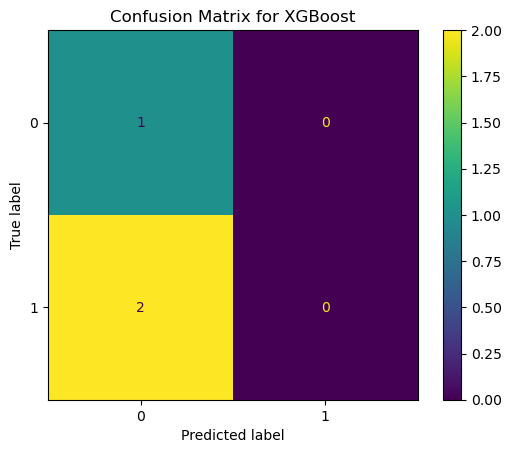

Processing: LogisticRegression
LogisticRegression: Brier Score = 0.2500

LogisticRegression Model
Brier Score: 0.25
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



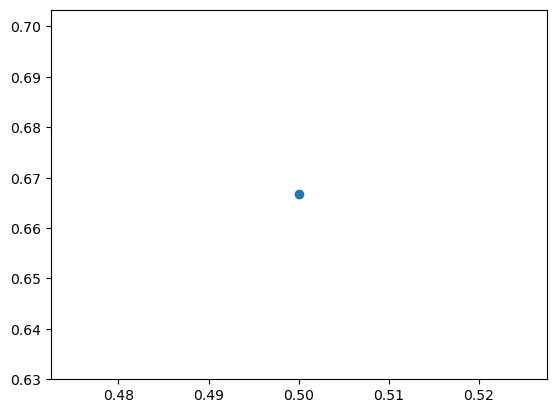

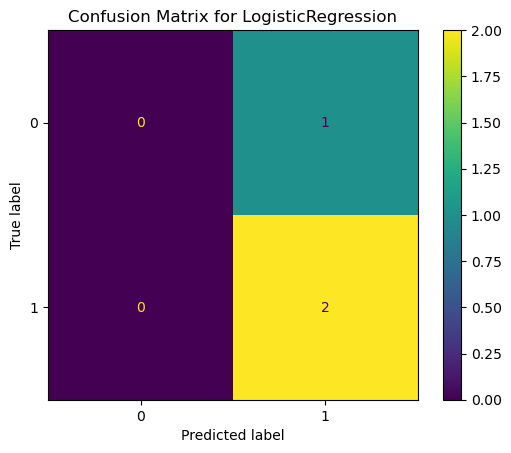

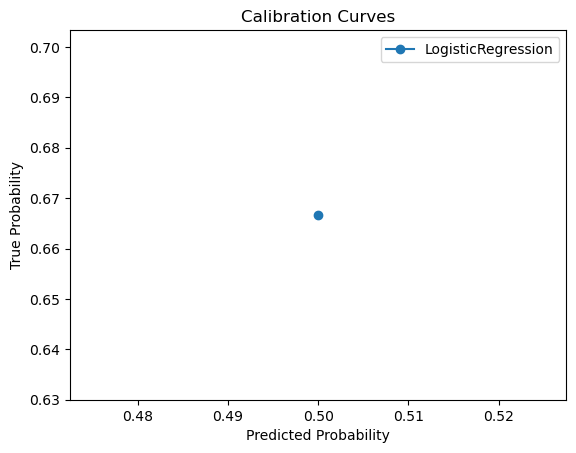

In [73]:
# 8. Training, Calibration & Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():
    from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

for name, model in models.items():
    print(f"Processing: {name}")

    # 1️⃣ Fit the base model first
    model.fit(X_train, y_train)

    # 2️⃣ Calibrate the already-fitted model
    calibrated = CalibratedClassifierCV(model, cv='prefit')
    calibrated.fit(X_train, y_train)

    # 3️⃣ Evaluate
    y_prob = calibrated.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, y_prob)
    print(f"{name}: Brier Score = {brier:.4f}")


    calibrated = CalibratedClassifierCV(model, cv='prefit')
    calibrated.fit(X_train, y_train)
    y_prob = calibrated.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, y_prob)
    y_pred = calibrated.predict(X_test)

    print(f"\n{name} Model")
    print("Brier Score:", round(brier, 4))
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix for {name}")
    plt.show()


    # Calibration Plot
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.title("Calibration Curves")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.legend()
plt.show()

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import numpy as np
# Note: SHAP code is commented out as it requires the library to be installed and 
# the feature names to be correctly defined, which we address below.

# --- 1. Load and Clean Data (Pre-requisite to define df and y) ---
# Replace this placeholder with your actual data loading/cleaning steps.
data = {
    'cleaned_resume': [
        'python sql machine learning', 
        'hr recruiting training', 
        'java spring developer', 
        'python aws cloud engineer',
        'customer service communication skills'
    ],
    'target_label': [1, 0, 1, 1, 0] 
}
df = pd.DataFrame(data)

# Ensure y is clean and defined
df = df.dropna(subset=['target_label'])
y = df['target_label'].astype(int)

# --- 2. Vectorize the Text Features (Pre-requisite to define X) ---
vectorizer = TfidfVectorizer(max_features=5000) 
X = vectorizer.fit_transform(df['cleaned_resume']).toarray()
feature_names = vectorizer.get_feature_names_out() # Save feature names for later!


# --- 3. Split the Data (Pre-requisite to define X_train, y_train, etc.) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=3, 
    random_state=42, 
    stratify=y 
)

print("X_train and y_train are now defined.")
# ----------------------------------------------------------------------


# --- 4. Scale numeric features (Your original step 6) ---
scaler = MinMaxScaler()
# X_train is successfully fit/transformed here
X_train_scaled = scaler.fit_transform(X_train) 
# X_test is transformed here
X_test_scaled = scaler.transform(X_test)


# --- 5. Train Model and Calculate Feature Importance (Your original step 9, corrected) ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
# Use the scaled data for training
rf.fit(X_train_scaled, y_train)

# **CORRECTION:** Use the feature names from the TfidfVectorizer, not DataFrame columns.
importances = pd.Series(
    rf.feature_importances_, 
    index=feature_names # Use the feature names we saved earlier
).sort_values(ascending=False)

print("\nTop 10 Important Features:\n", importances.head(10))

# --- 6. SHAP Analysis (Use scaled data for consistency) ---
# If you have the shap library installed, you can uncomment this block.
# Ensure you use the scaled X_test data.
#import shap
#explainer = shap.Explainer(rf, X_test_scaled, algorithm="auto")
#shap_values = explainer(X_test_scaled[:len(X_test_scaled)])
#shap.plots.bar(shap_values)

X_train and y_train are now defined.

Top 10 Important Features:
 skills           0.211538
customer         0.153846
spring           0.134615
service          0.134615
developer        0.134615
java             0.115385
communication    0.115385
aws              0.000000
cloud            0.000000
learning         0.000000
dtype: float64


Generating SHAP Summary Bar Plot...


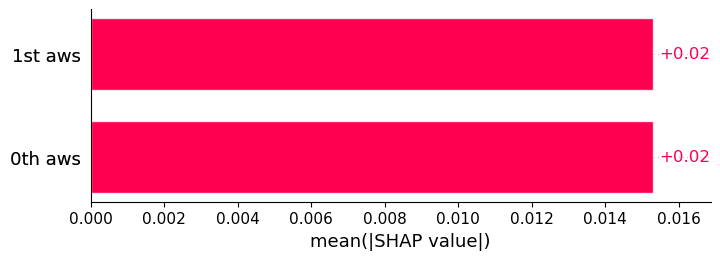

In [80]:
import shap
import matplotlib.pyplot as plt

# Check if the required variables are defined (run the data setup steps if not)
try:
    _ = rf
    _ = X_test_scaled
    _ = feature_names
except NameError:
    print("FATAL ERROR: Required variables (rf, X_test_scaled, feature_names) are not defined. Please re-run the data setup and modeling cells.")
    # Exit or stop execution here if running in a script
    raise # Re-raise the NameError if it was the original issue

# --- 1. Use the specialized TreeExplainer for RandomForest ---
explainer = shap.TreeExplainer(rf)

# --- 2. Calculate SHAP values ---
# Use the SCALED test data. We calculate for the positive class (index 1).
num_samples = min(300, X_test_scaled.shape[0]) 
shap_values_raw = explainer.shap_values(X_test_scaled[:num_samples])

# For binary classification, we focus on the positive class (index 1)
# which has the shape (num_samples, num_features).
positive_class_shap_values = shap_values_raw[1]


# --- 3. CREATE a shap.Explanation object (CRITICAL STEP FOR PLOTTING) ---
# This step explicitly links the calculated values, background data, and feature names.
shap_explanation = shap.Explanation(
    values=positive_class_shap_values,
    base_values=explainer.expected_value[1], # Expected value for the positive class
    data=X_test_scaled[:num_samples],
    feature_names=feature_names.tolist() # Convert the NumPy array of names to a list
)

# --- 4. Generate the Plot ---
print("Generating SHAP Summary Bar Plot...")
# Use the Explanation object directly in the plot function
# The plot will automatically use the feature_names stored in shap_explanation.
shap.plots.bar(shap_explanation, show_data=False)
plt.show()
